# 02 Exploratory Data Analysis

This notebook uses the processed match-level dataset from `01_data_cleaning.ipynb` and focuses on distributions, ATP/WTA comparisons, outlier checks, and correlations.

# Setup

Run this cell first so notebooks can import helpers from the `src/` folder.

In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

In [ ]:
from src.visualization import plot_hist, plot_box

In [ ]:
import pandas as pd

processed_path = PROJECT_ROOT / "data" / "processed" / "analysis_df.csv"
if not processed_path.exists():
    raise FileNotFoundError(
        f"{processed_path} not found. Run notebooks/01_data_cleaning.ipynb first."
    )
analysis_df = pd.read_csv(processed_path)
analysis_df.head()

In [ ]:
df = analysis_df.copy()

In [ ]:
df_atp = df[df['tour'] == 'atp']
df_wta = df[df['tour'] == 'wta']

In [ ]:
absolute_cols = [
    'p1_avg_run_distance',
    'p2_avg_run_distance',
    'p1_net_win_pct',
    'p2_net_win_pct',
    'p1_break_win_pct',
    'p2_break_win_pct',
    'p1_ace_rate',
    'p2_ace_rate',
    'p1_df_rate',
    'p2_df_rate',
    'p1_winner_rate',
    'p2_winner_rate',
    'p1_ue_rate',
    'p2_ue_rate',
    'p1_points_win_pct',
    'p2_points_win_pct'
]

serve_cols = [
    'p1_ServeWidth_B',
    'p2_ServeWidth_B',
    'p1_ServeWidth_BC',
    'p2_ServeWidth_BC',
    'p1_ServeWidth_BW',
    'p2_ServeWidth_BW',
    'p1_ServeWidth_C',
    'p2_ServeWidth_C',
    'p1_ServeWidth_W',
    'p2_ServeWidth_W',
    'p1_ServeDepth_CTL',
    'p2_ServeDepth_CTL',
    'p1_ServeDepth_NCTL',
    'p2_ServeDepth_NCTL',
    'p1_ReturnDepth_D',
    'p2_ReturnDepth_D',
    'p1_ReturnDepth_ND',
    'p2_ReturnDepth_ND'
]

match_cols = [
    'points_played',
    'sets_played',
    'rallies_count',
    'max_serve_speed_mph',
    'avg_rally_count'
]

diff_cols = [
    'winner_rate_diff',
    'ue_rate_diff',
    'ace_rate_diff',
    'df_rate_diff',
    'break_win_pct_diff',
    'net_win_pct_diff',
    'points_win_pct_diff',
    'distance_run_diff',
    'servewidth_b_diff',
    'servewidth_bc_diff',
    'servewidth_bw_diff',
    'servewidth_c_diff',
    'servewidth_w_diff',
    'servedepth_ctl_diff',
    'servedepth_nctl_diff',
    'returndepth_d_diff',
    'returndepth_nd_diff'
]


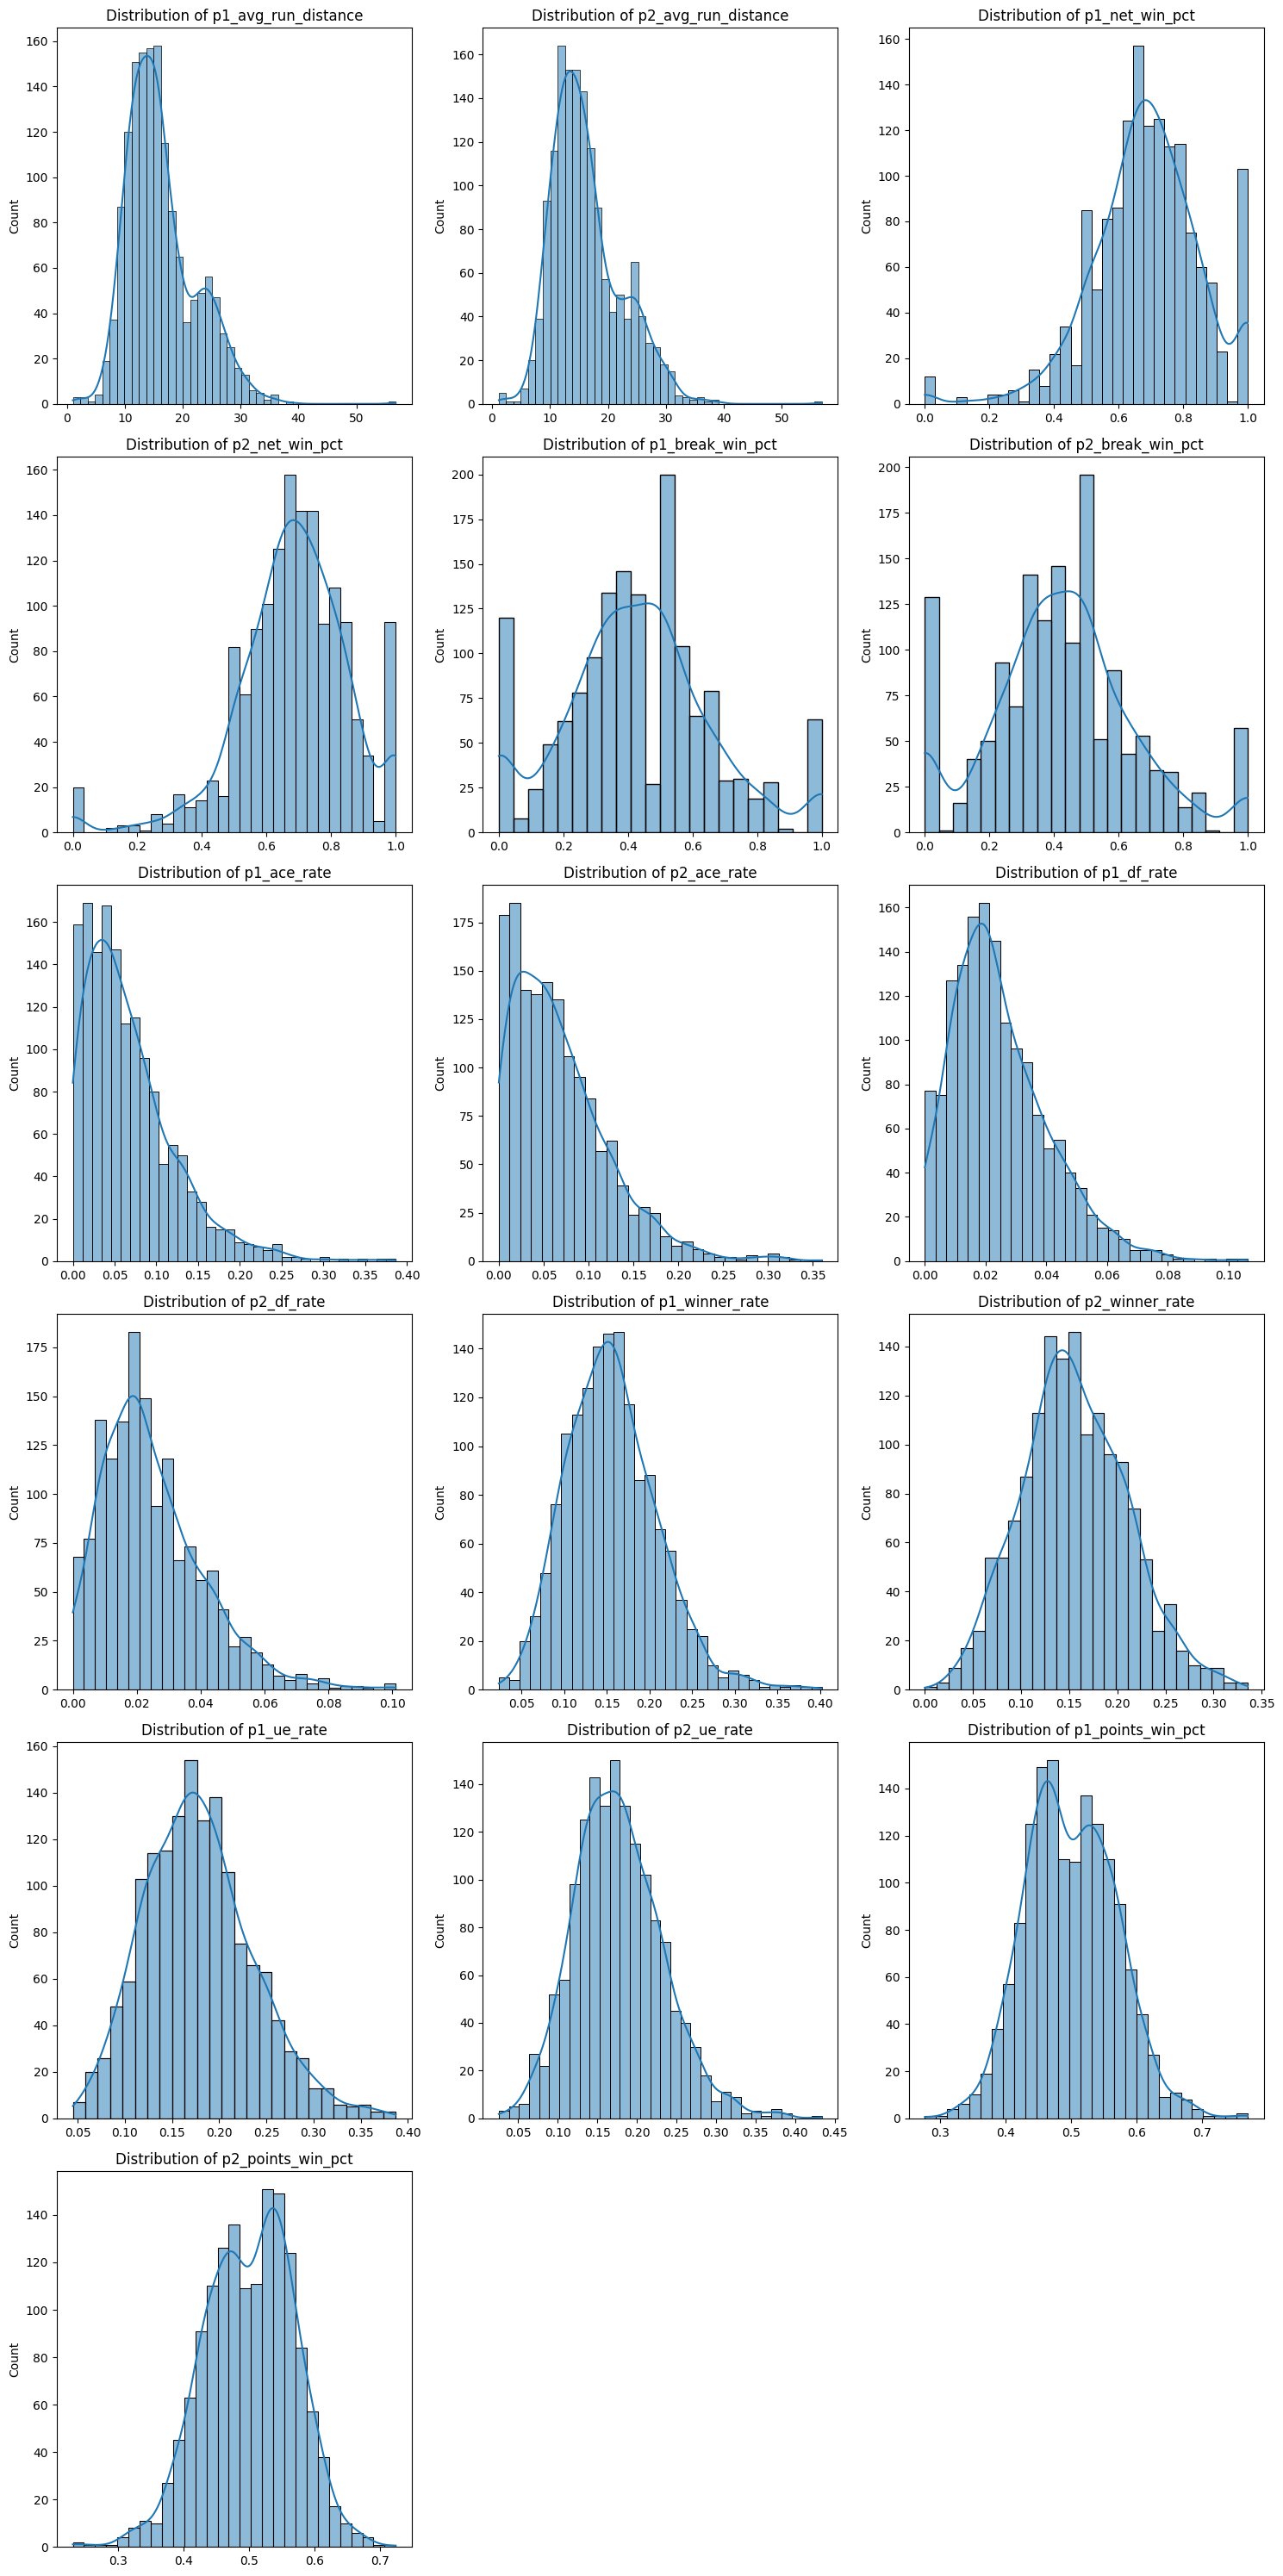

In [ ]:
plot_hist(df, absolute_cols, n_cols=3)

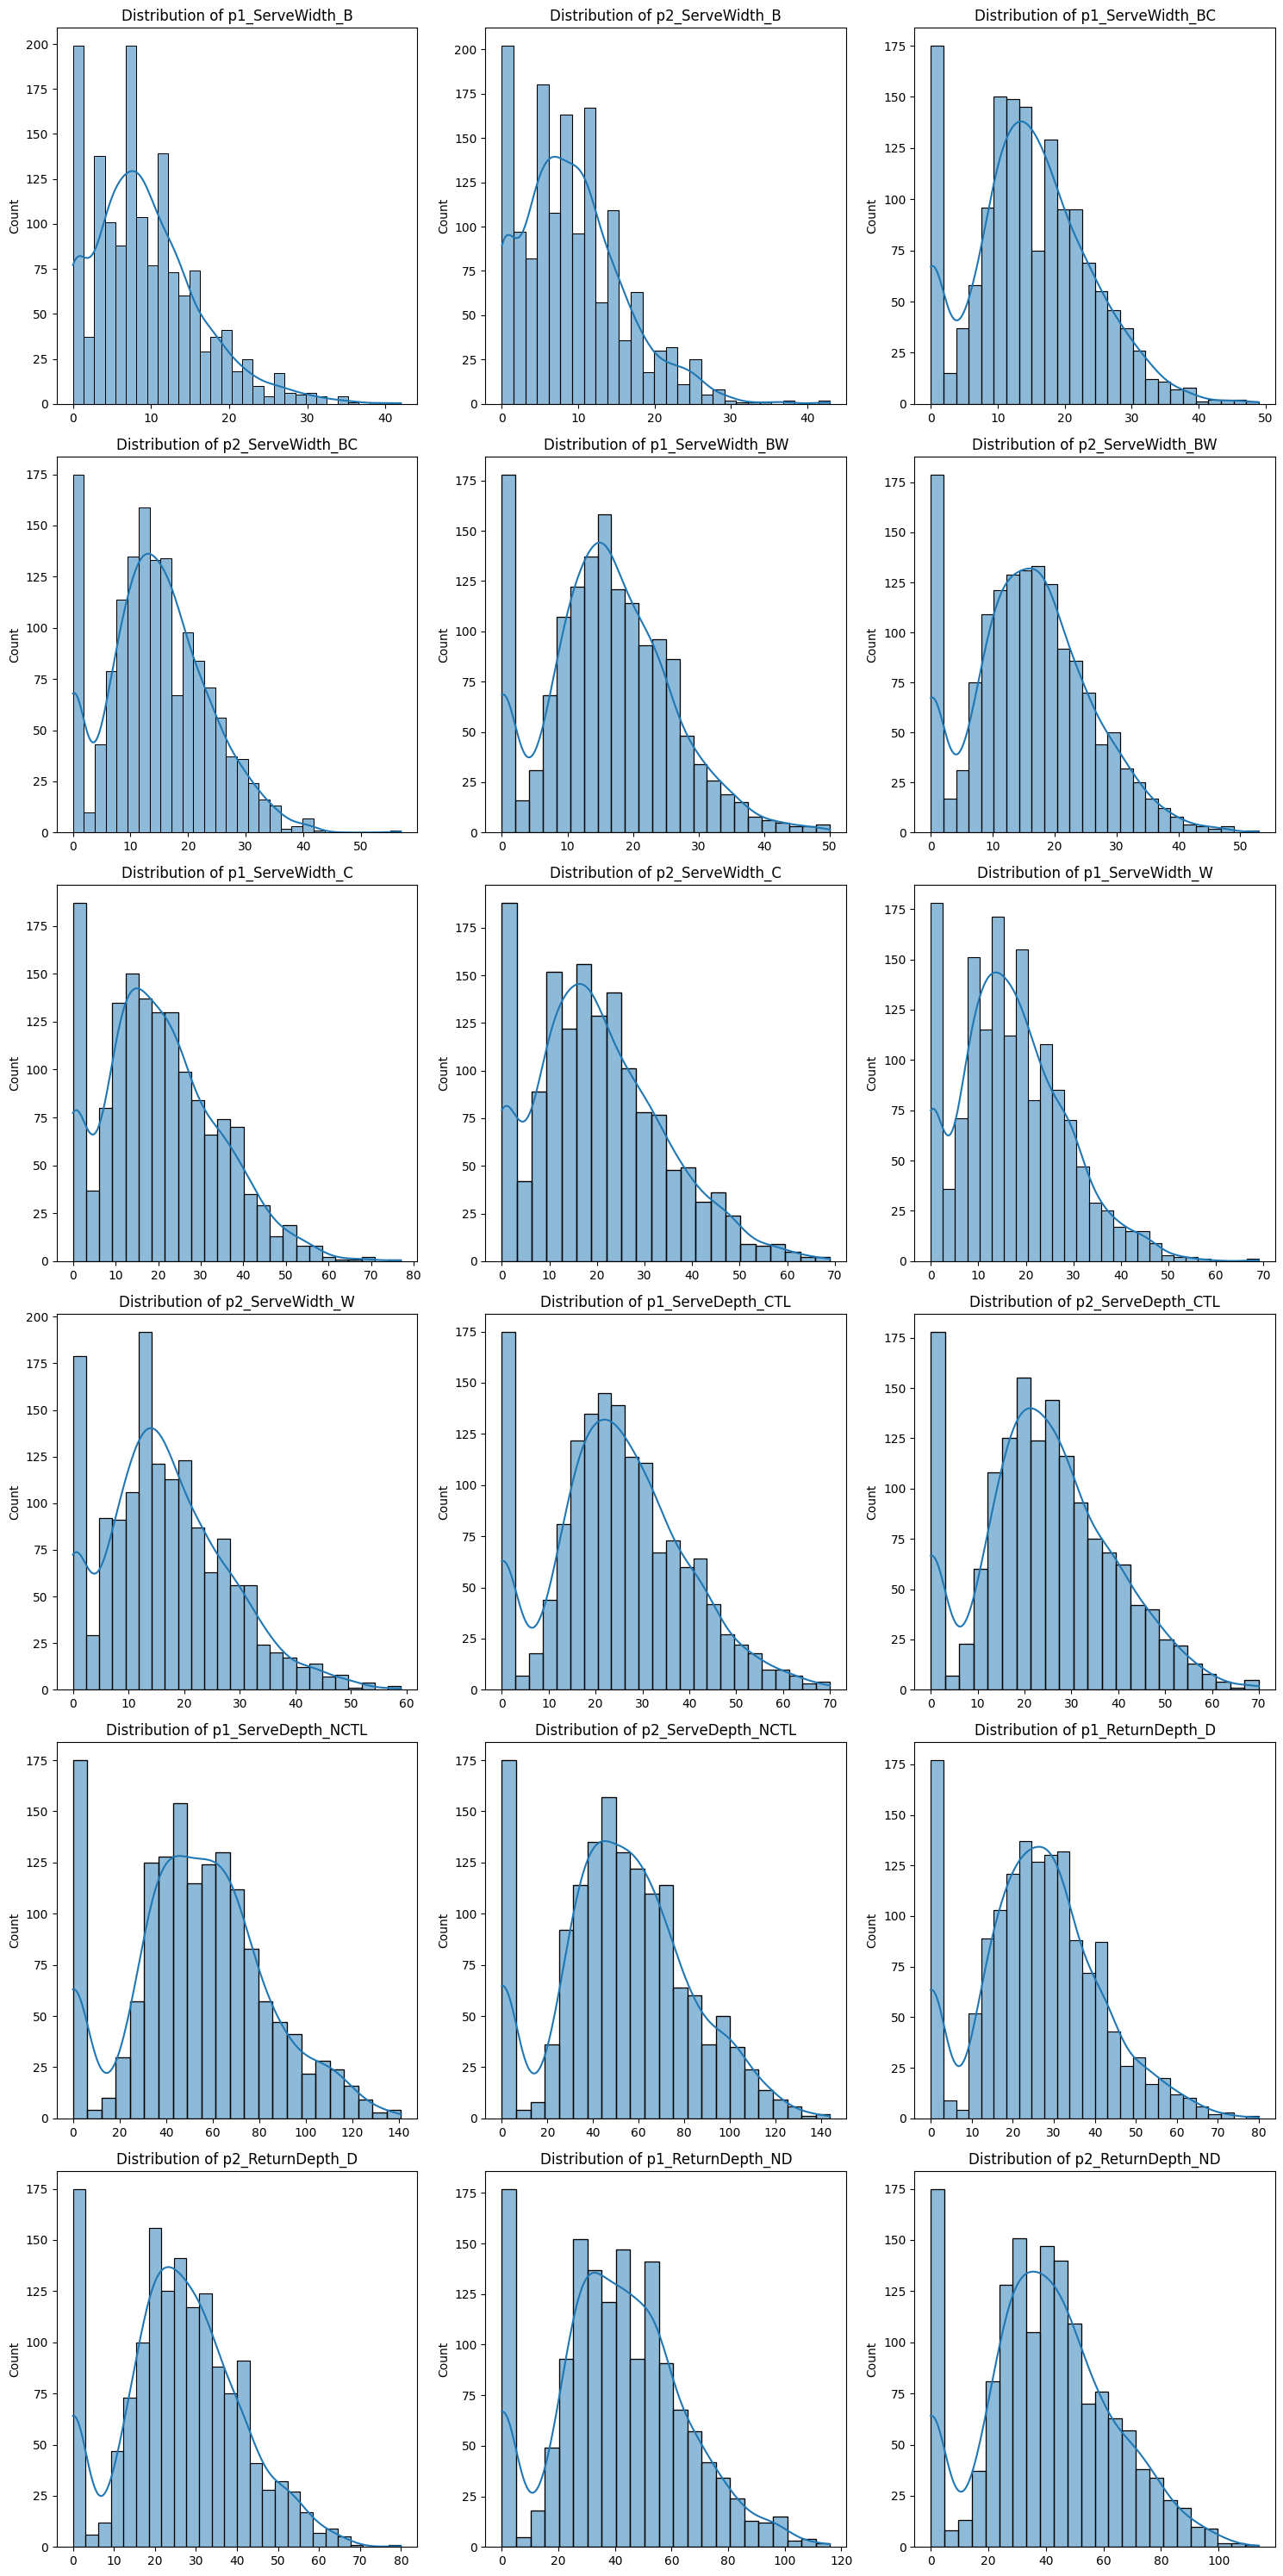

In [ ]:
plot_hist(df, serve_cols, n_cols=3)

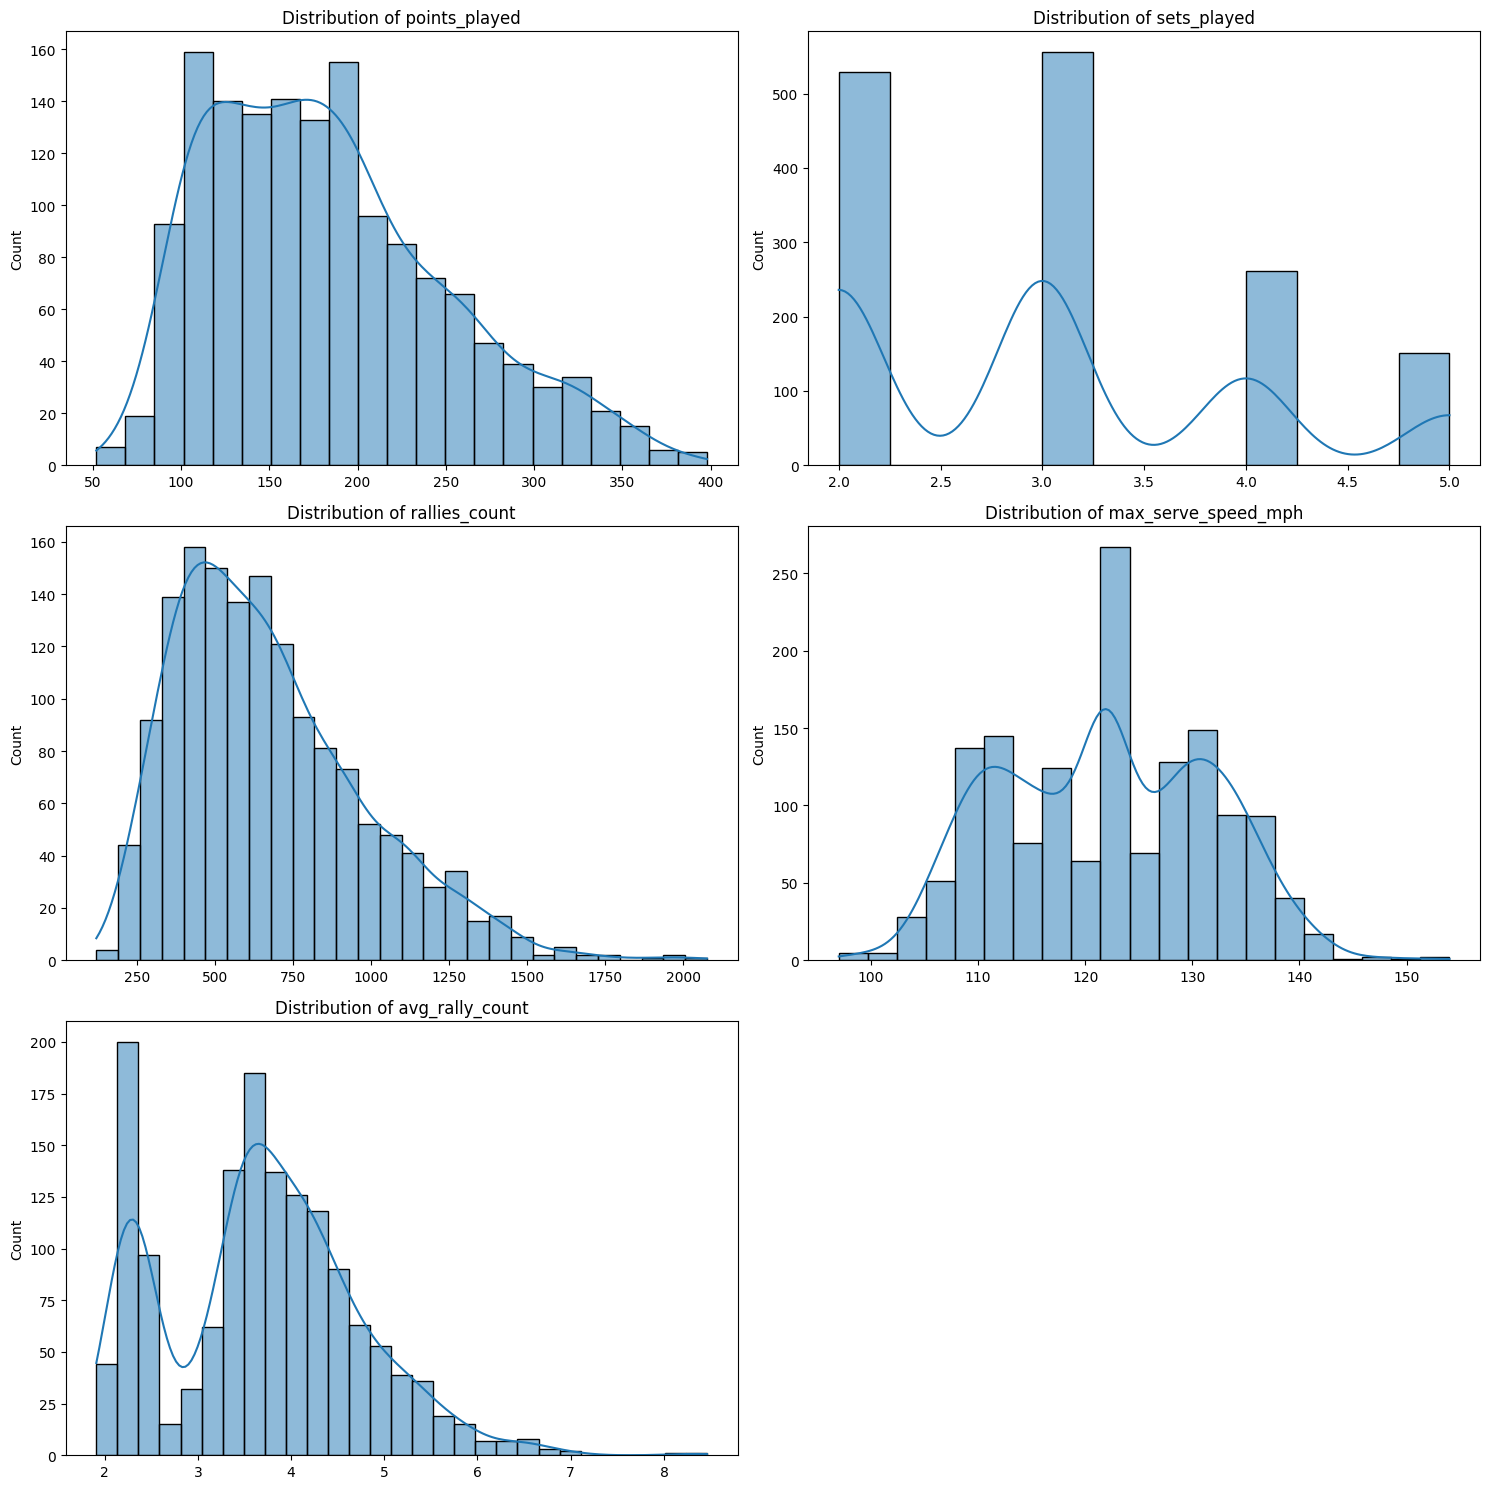

In [ ]:
plot_hist(df, match_cols, n_cols=2)

In [ ]:
#get the statistics for the match_cols
df[match_cols].describe()

,points_played,sets_played,rallies_count,max_serve_speed_mph,avg_rally_count
count,1498.000000,1498.000000,1498.000000,1498.000000,1498.000000
mean,183.774366,3.023364,673.406807,121.908949,3.693500
std,67.799036,0.965048,304.639560,9.736486,1.035166
min,52.000000,2.000000,119.421927,97.000000,1.911104
25%,130.000000,2.000000,437.618193,114.000000,2.989836
50%,174.000000,3.000000,618.868193,121.908949,3.680448
75%,225.000000,4.000000,848.566216,130.000000,4.322042
max,398.000000,5.000000,2075.543138,154.000000,8.462145


In [ ]:
df[df['rallies_count'] > 1500][match_cols]

,points_played,sets_played,rallies_count,max_serve_speed_mph,avg_rally_count
7,347,5,2075.543138,122.0,5.981392
13,238,4,1555.000000,127.0,6.533613
22,372,5,1654.879585,125.0,4.448601
44,343,5,1520.254101,125.0,4.432228
116,258,4,1660.174538,137.0,6.434785
124,341,5,1889.956168,128.0,5.542393
306,355,5,1952.792393,131.0,5.500824
372,322,5,1592.250051,140.0,4.944876
563,323,4,1760.736385,134.0,5.451196
601,305,5,1507.759941,131.0,4.943475


In [ ]:
df[df['avg_rally_count'] > 6][match_cols]

,points_played,sets_played,rallies_count,max_serve_speed_mph,avg_rally_count
13,238,4,1555.000000,127.0,6.533613
116,258,4,1660.174538,137.0,6.434785
122,214,3,1329.992969,132.0,6.214920
133,119,2,974.265780,98.0,8.187107
140,164,3,1120.421927,103.0,6.831841
144,167,3,1089.876306,111.0,6.526205
242,123,2,740.710963,110.0,6.022040
312,144,2,871.132890,136.0,6.049534
446,113,2,678.843853,107.0,6.007468
591,148,3,985.843853,126.0,6.661107


In [ ]:
df[df['max_serve_speed_mph'] < 100][match_cols]

,points_played,sets_played,rallies_count,max_serve_speed_mph,avg_rally_count
133,119,2,974.265780,98.0,8.187107
932,136,2,488.707594,99.0,3.593438
1214,190,3,1294.496027,99.0,6.813137
1385,161,3,876.620876,97.0,5.444850
1431,121,2,470.108935,99.0,3.885198


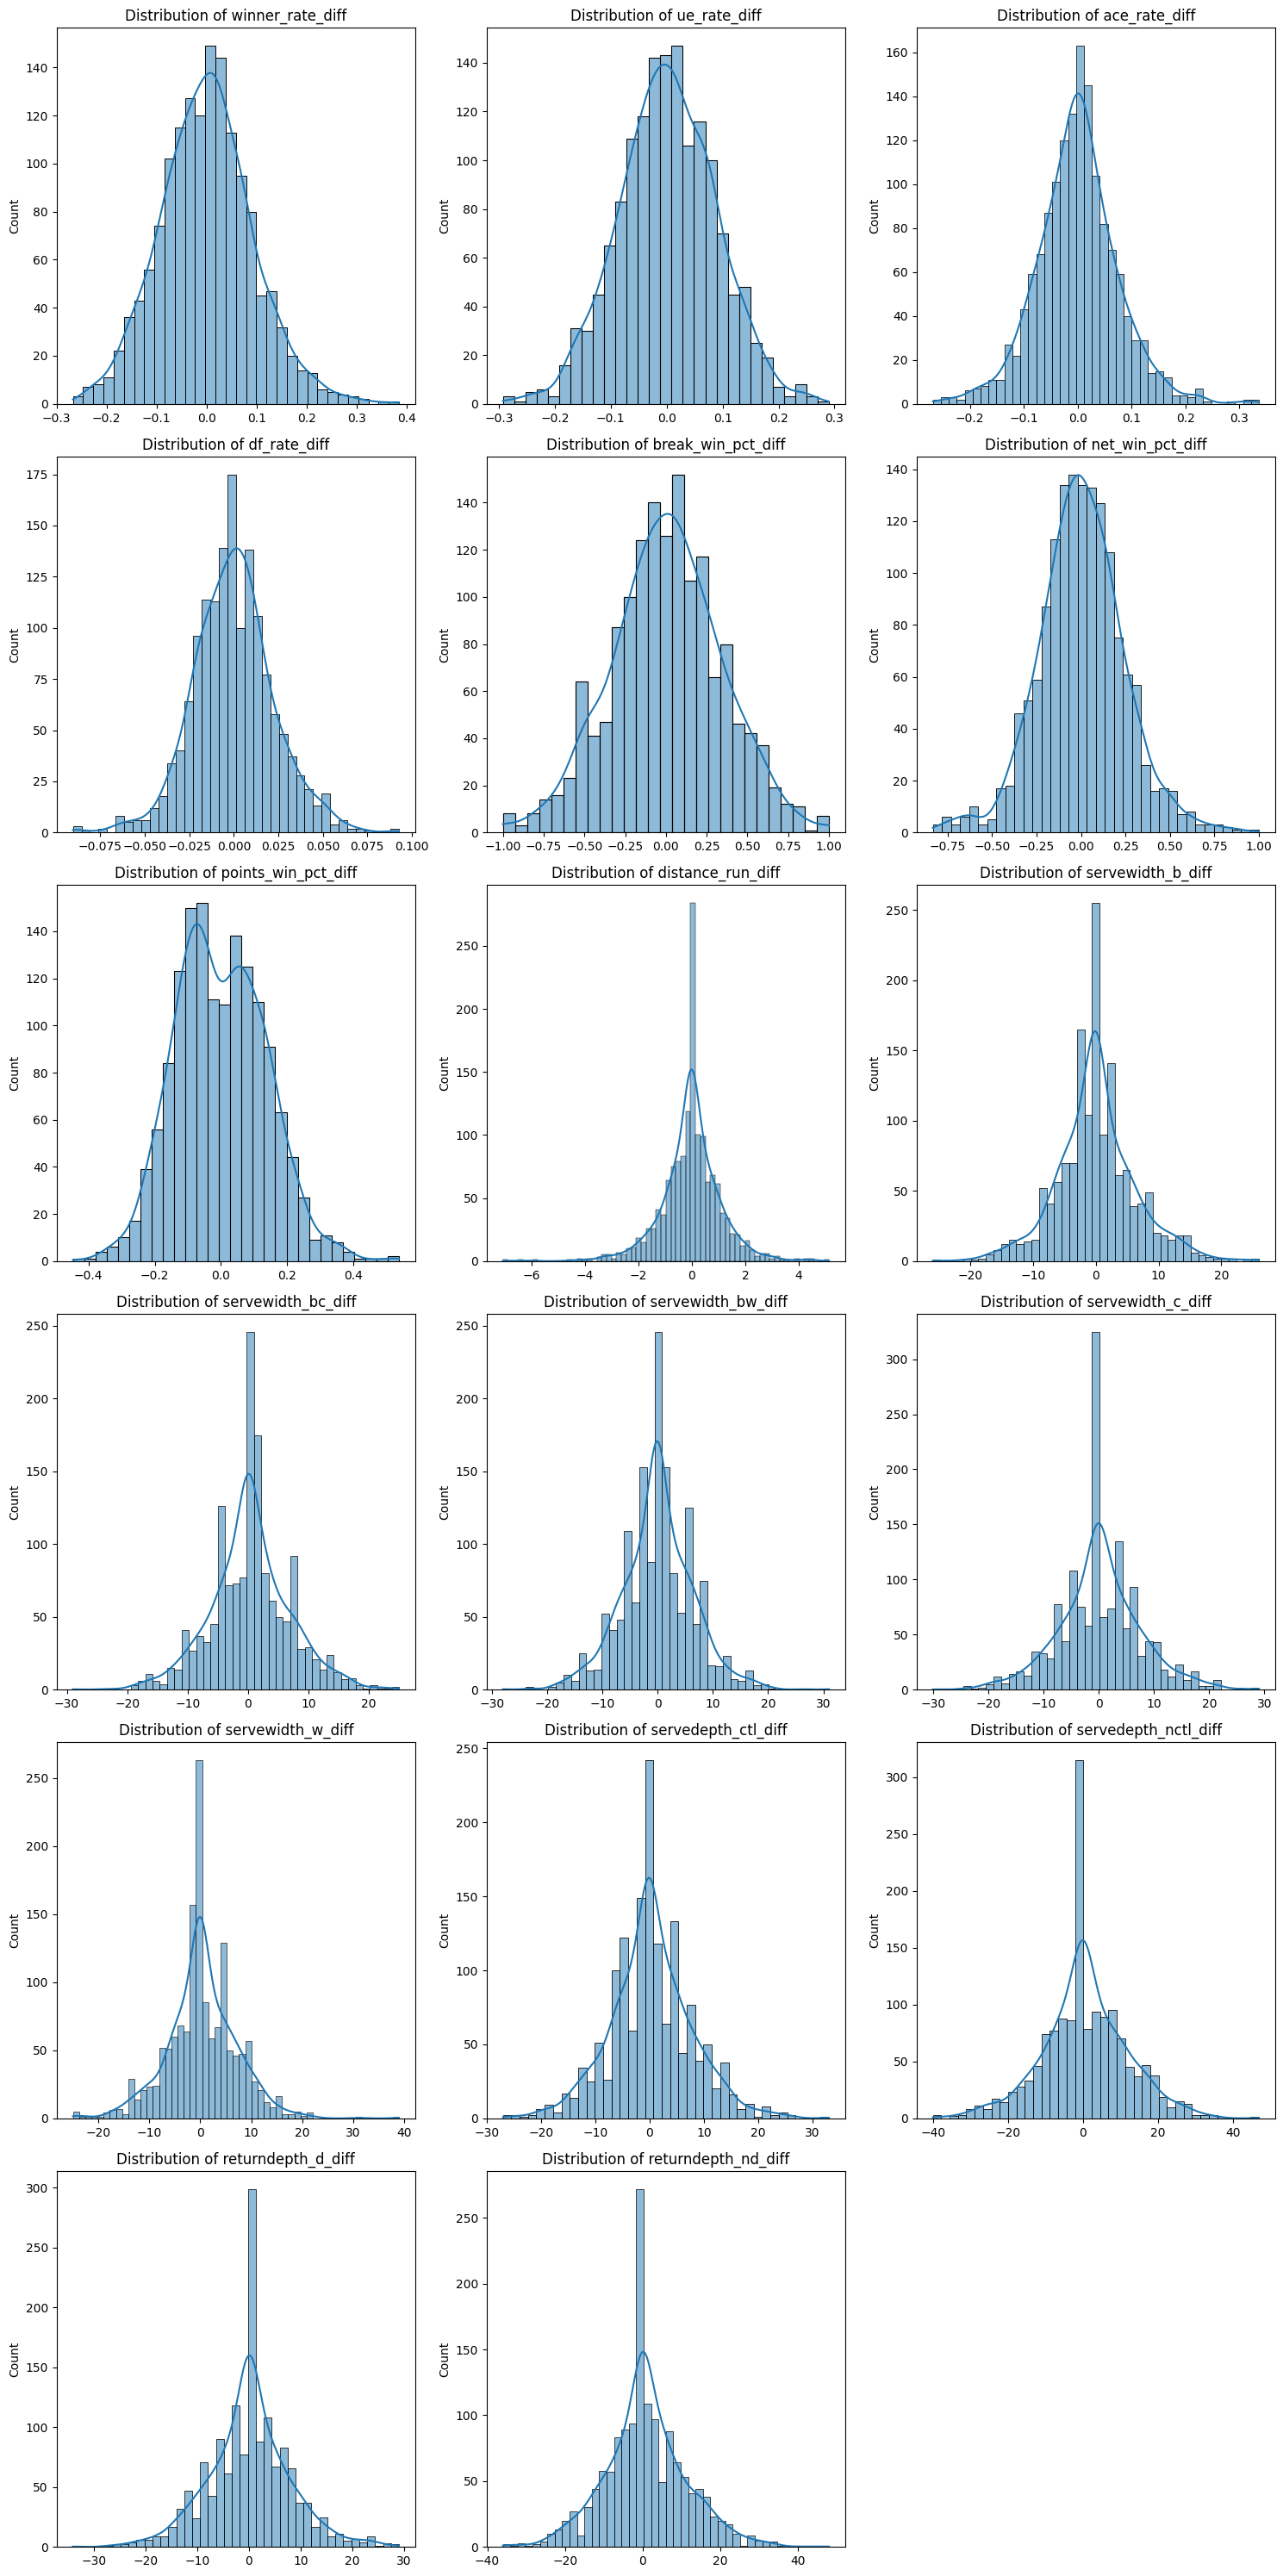

In [ ]:
plot_hist(df, diff_cols, n_cols=3)

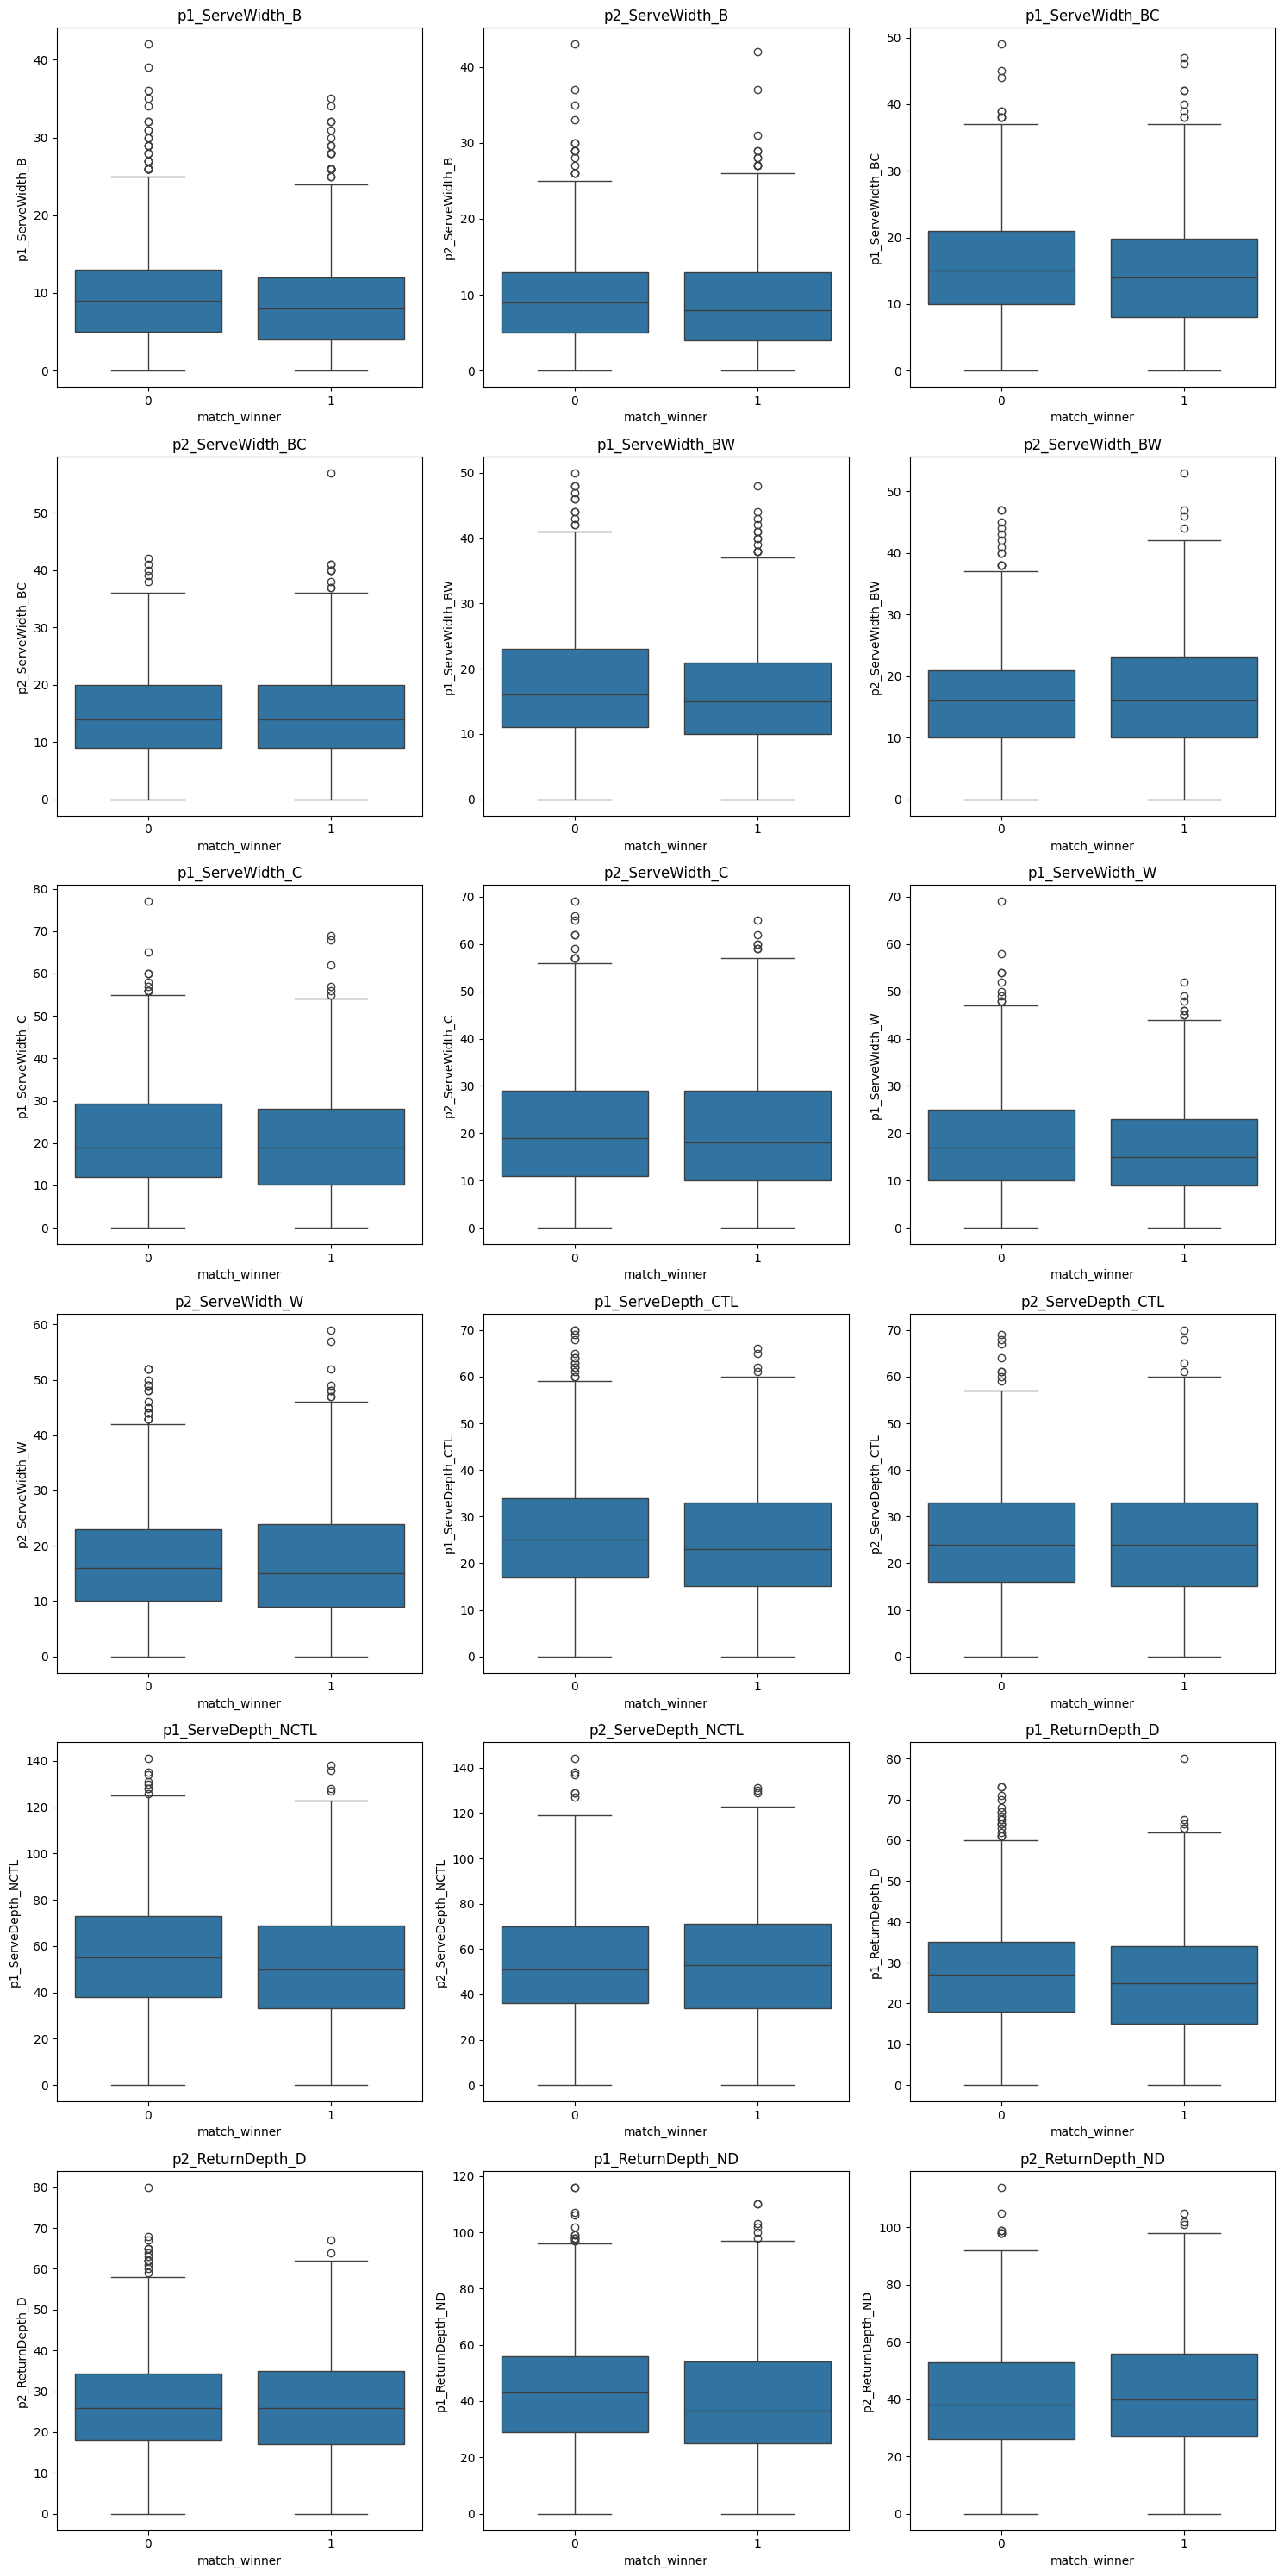

In [ ]:
plot_box(df, serve_cols, n_cols=3)

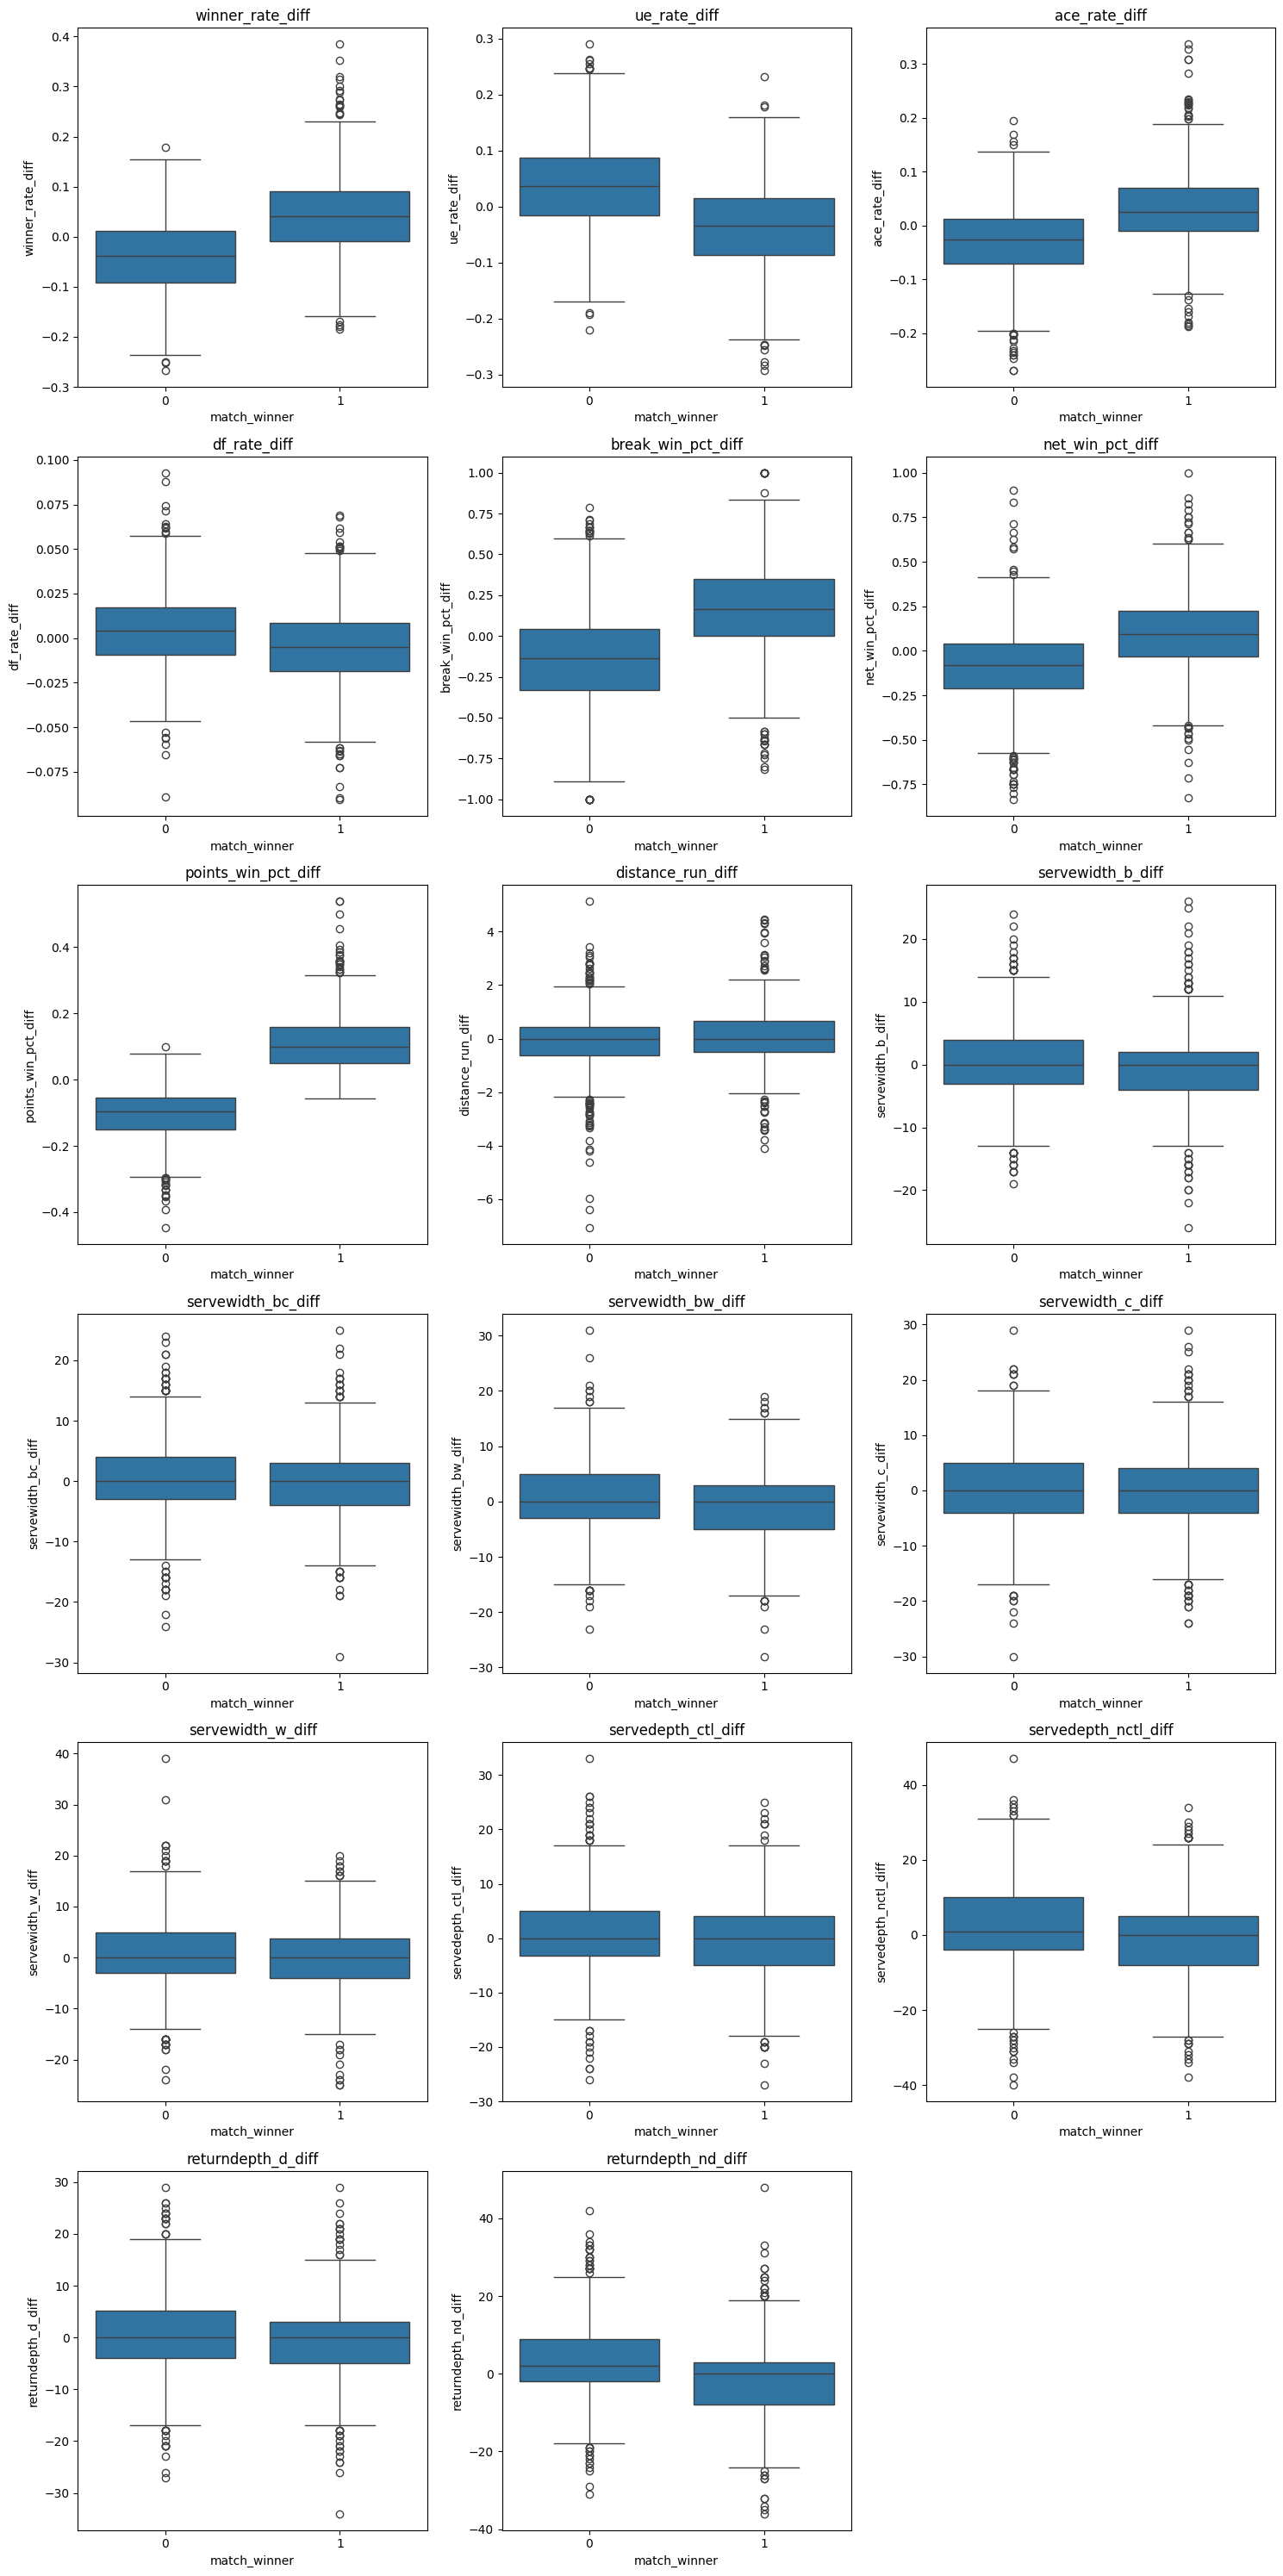

In [ ]:
plot_box(df, diff_cols, n_cols=3)

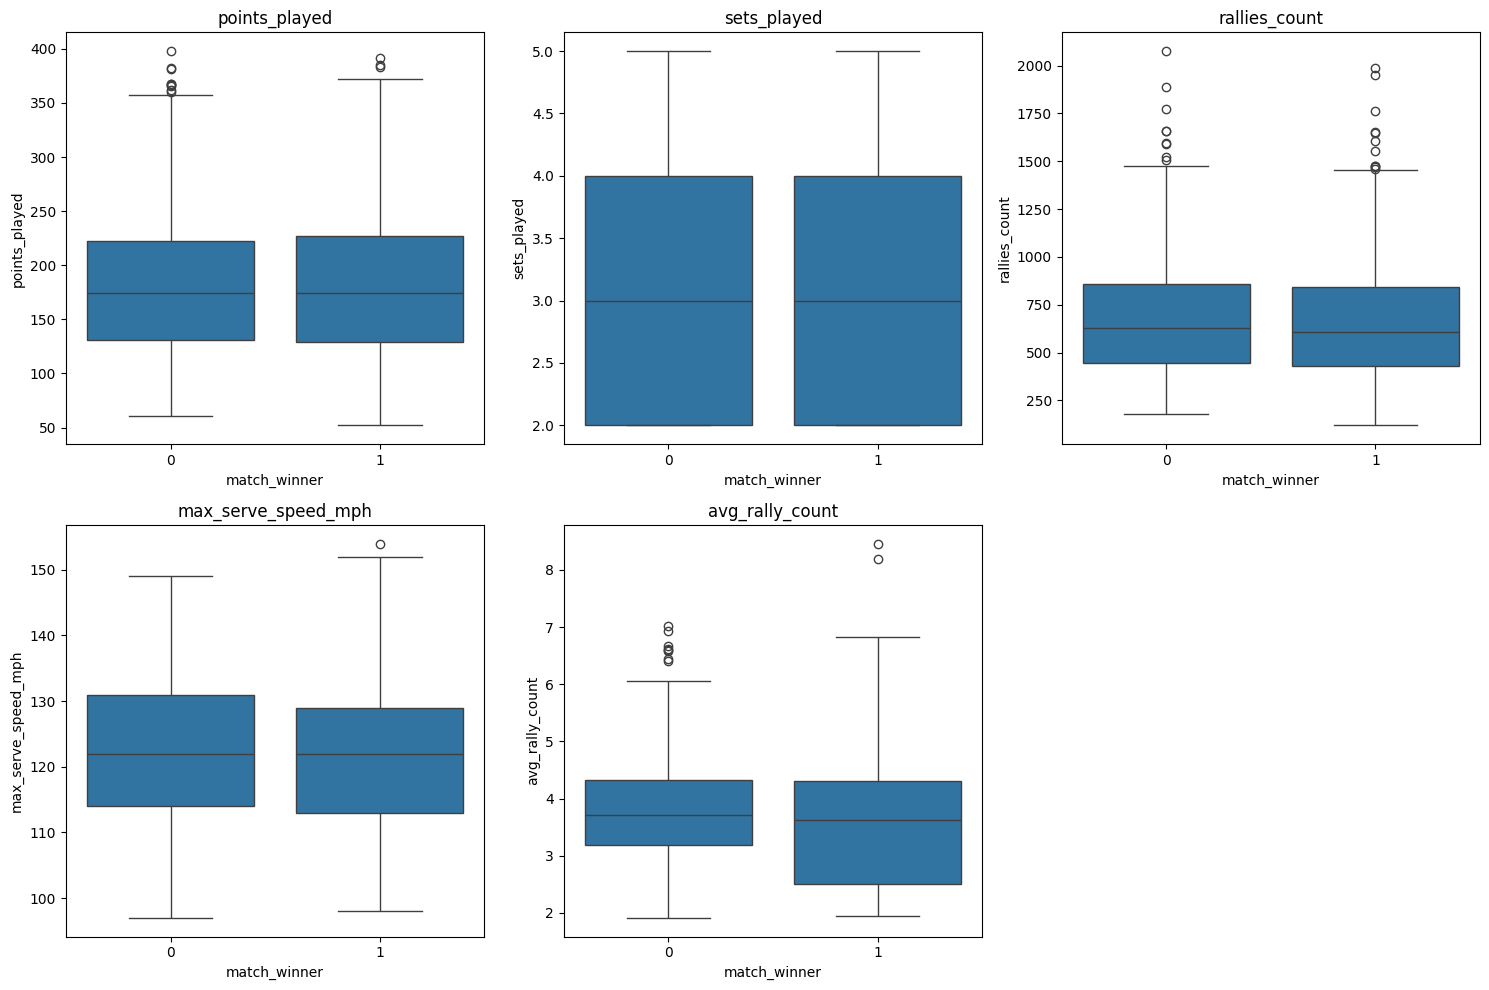

In [ ]:
plot_box(df, match_cols, n_cols=3)

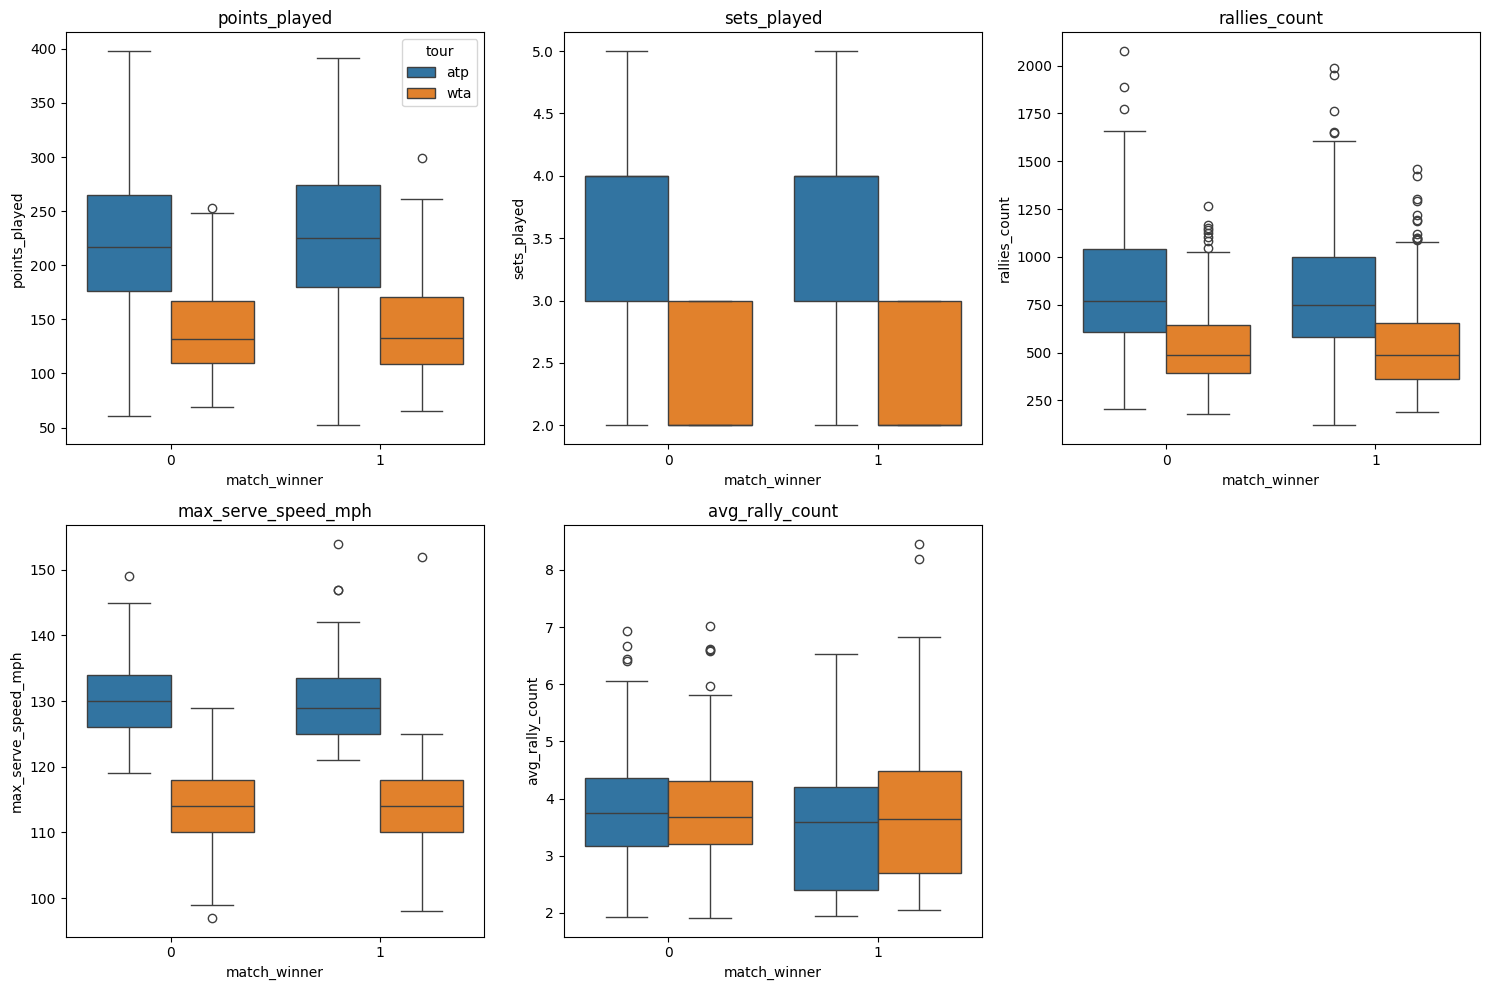

In [ ]:
plot_box(df, match_cols, hue='tour',n_cols=3)

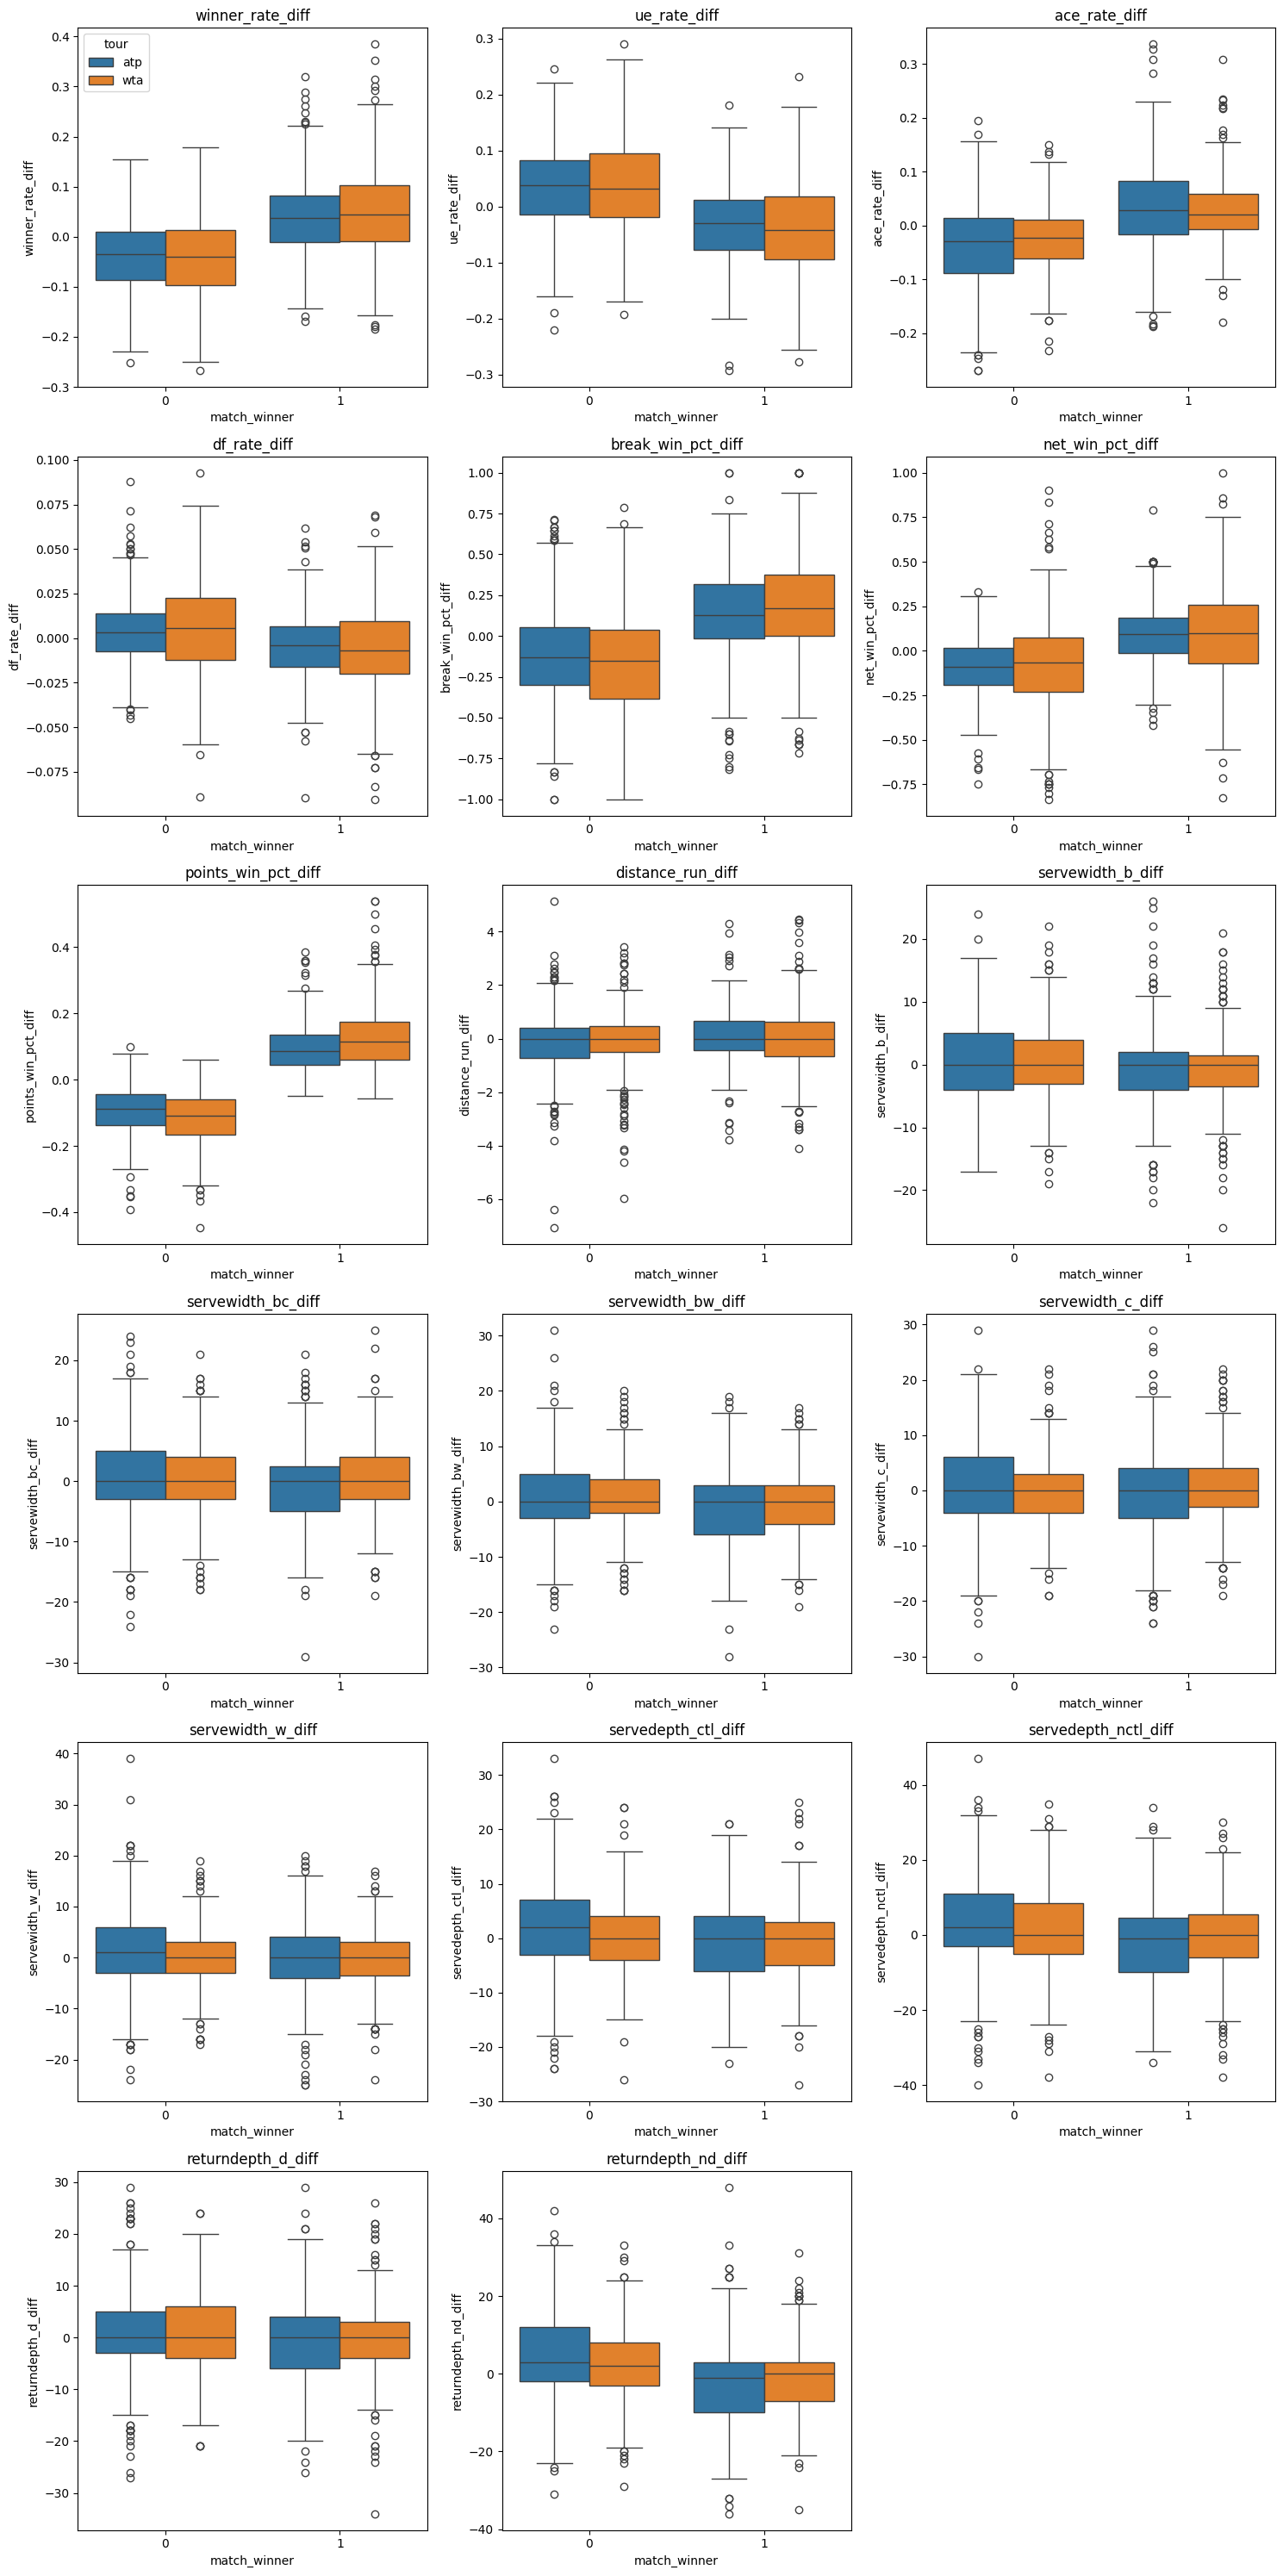

In [ ]:
plot_box(df, diff_cols, hue='tour', n_cols=3)

In [ ]:
serve_diffs = [c for c in df.columns if 'servewidth' in c and 'diff' in c]

# Calculate the absolute difference in means between P1 wins and P2 wins
importance = []
for col in serve_diffs:
    mean_1 = df[df['match_winner'] == 1][col].mean()
    mean_0 = df[df['match_winner'] == 0][col].mean()
    diff = abs(mean_1 - mean_0)
    importance.append({'feature': col, 'mean_diff': diff})

importance_df = pd.DataFrame(importance).sort_values('mean_diff', ascending=False)
print("Serve Width Features ranked by separation between winners/losers:")
display(importance_df)

Serve Width Features ranked by separation between winners/losers:


,feature,mean_diff
2,servewidth_bw_diff,1.614524
0,servewidth_b_diff,1.336869
4,servewidth_w_diff,1.253843
1,servewidth_bc_diff,0.906782
3,servewidth_c_diff,0.521188


In [ ]:
depth_diffs = [c for c in df.columns if ('servedepth' in c or 'returndepth' in c) and 'diff' in c]

# Calculate the absolute difference in means for depth features
depth_importance = []
for col in depth_diffs:
    mean_1 = df[df['match_winner'] == 1][col].mean()
    mean_0 = df[df['match_winner'] == 0][col].mean()
    diff = abs(mean_1 - mean_0)
    depth_importance.append({'feature': col, 'mean_diff': diff})

importance_depth_df = pd.DataFrame(depth_importance).sort_values('mean_diff', ascending=False)
print('Depth and Return Features ranked by separation:')
display(importance_depth_df)

Depth and Return Features ranked by separation:


,feature,mean_diff
3,returndepth_nd_diff,5.209710
1,servedepth_nctl_diff,3.968695
0,servedepth_ctl_diff,1.664510
2,returndepth_d_diff,1.414520


In [ ]:
df['is_atp'] = (df['tour'] == 'atp').astype(int)

In [ ]:
df['is_atp'].unique()

array([1, 0])

Text(0.5, 1.0, 'Correlation Analysis')

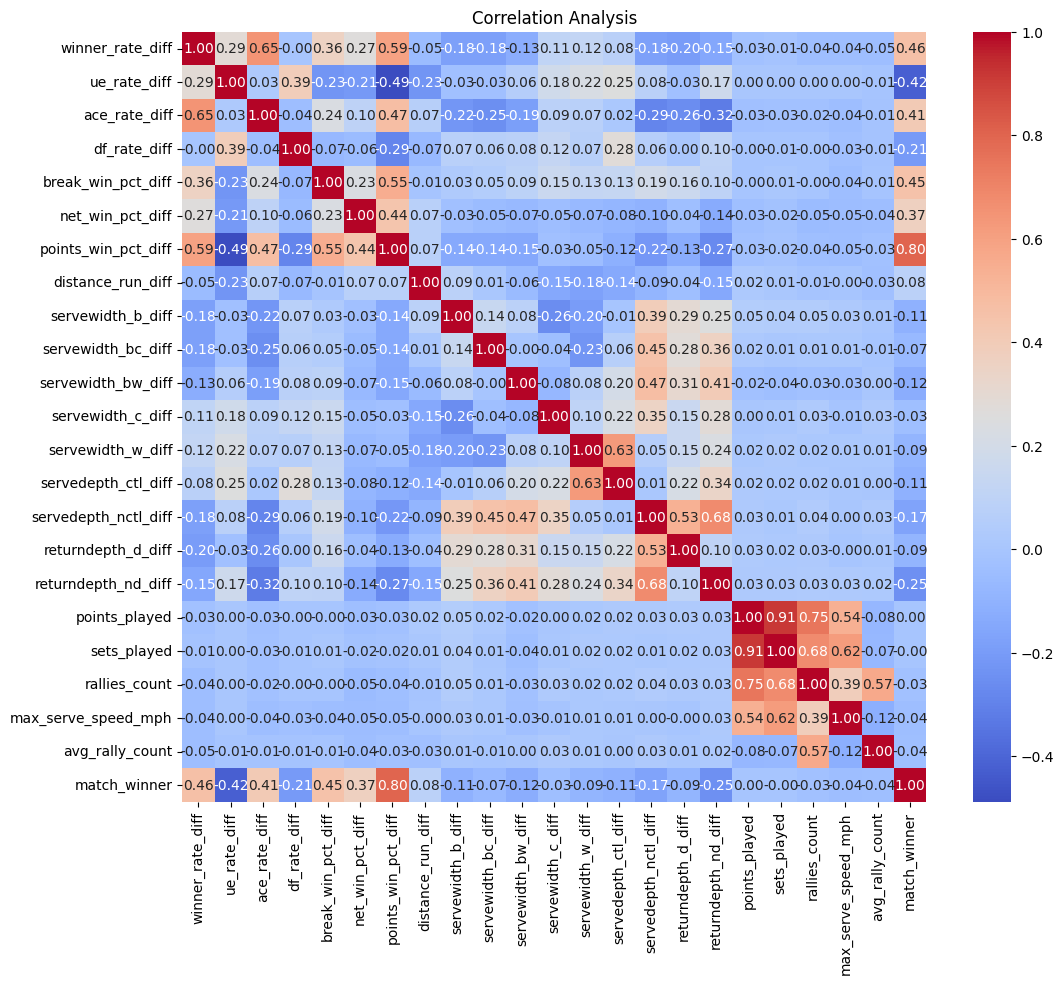

In [ ]:
#correlation analysis
# Wrap 'match_winner' in a list to allow concatenation with the diff_cols list
corr_df = df[diff_cols + match_cols + ['match_winner']]
corr_matrix = corr_df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Analysis')

In [ ]:
# Calculate correlation specifically with match_winner
correlations = corr_matrix['match_winner'].drop('match_winner')

# Create a DataFrame for ranking
ranking_df = pd.DataFrame({
    'feature': correlations.index,
    'correlation': correlations.values,
    'abs_correlation': correlations.abs().values
})

# Sort by absolute correlation strength
ranking_df = ranking_df.sort_values(by='abs_correlation', ascending=False).reset_index(drop=True)

print("Features ranked by correlation with match_winner:")
display(ranking_df)

Features ranked by correlation with match_winner:


,feature,correlation,abs_correlation
0,points_win_pct_diff,8.021299e-01,8.021299e-01
1,winner_rate_diff,4.619202e-01,4.619202e-01
2,break_win_pct_diff,4.512105e-01,4.512105e-01
3,ue_rate_diff,-4.207440e-01,4.207440e-01
4,ace_rate_diff,4.088324e-01,4.088324e-01
5,net_win_pct_diff,3.721115e-01,3.721115e-01
6,returndepth_nd_diff,-2.450565e-01,2.450565e-01
7,df_rate_diff,-2.074937e-01,2.074937e-01
8,servedepth_nctl_diff,-1.727807e-01,1.727807e-01
9,servewidth_bw_diff,-1.249070e-01,1.249070e-01


In [ ]:
corr_df = df_atp[diff_cols + match_cols + ['match_winner']]
corr_matrix = corr_df.corr()
correlations = corr_matrix['match_winner'].drop('match_winner')

# Create a DataFrame for ranking
ranking_df_atp = pd.DataFrame({
    'feature': correlations.index,
    'correlation': correlations.values,
    'abs_correlation': correlations.abs().values
})

# Sort by absolute correlation strength
ranking_df_atp = ranking_df_atp.sort_values(by='abs_correlation', ascending=False).reset_index(drop=True)

print("Features ranked by correlation with match_winner:")
display(ranking_df_atp)

Features ranked by correlation with match_winner:


,feature,correlation,abs_correlation
0,points_win_pct_diff,0.800667,0.800667
1,net_win_pct_diff,0.484392,0.484392
2,winner_rate_diff,0.465593,0.465593
3,ue_rate_diff,-0.431344,0.431344
4,break_win_pct_diff,0.420073,0.420073
5,ace_rate_diff,0.406542,0.406542
6,returndepth_nd_diff,-0.280835,0.280835
7,servedepth_nctl_diff,-0.226551,0.226551
8,df_rate_diff,-0.198220,0.198220
9,servedepth_ctl_diff,-0.150391,0.150391


In [ ]:
corr_df = df_wta[diff_cols + match_cols + ['match_winner']]
corr_matrix = corr_df.corr()
correlations = corr_matrix['match_winner'].drop('match_winner')

# Create a DataFrame for ranking
ranking_df_wta = pd.DataFrame({
    'feature': correlations.index,
    'correlation': correlations.values,
    'abs_correlation': correlations.abs().values
})

# Sort by absolute correlation strength
ranking_df_wta = ranking_df_wta.sort_values(by='abs_correlation', ascending=False).reset_index(drop=True)

print("Features ranked by correlation with match_winner:")
display(ranking_df_wta)

Features ranked by correlation with match_winner:


,feature,correlation,abs_correlation
0,points_win_pct_diff,0.811542,0.811542
1,break_win_pct_diff,0.479622,0.479622
2,winner_rate_diff,0.461170,0.461170
3,ace_rate_diff,0.423680,0.423680
4,ue_rate_diff,-0.414325,0.414325
5,net_win_pct_diff,0.304659,0.304659
6,df_rate_diff,-0.218465,0.218465
7,returndepth_nd_diff,-0.201773,0.201773
8,servewidth_b_diff,-0.129736,0.129736
9,servedepth_nctl_diff,-0.111899,0.111899
